In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [46]:
train_images = np.load('/content/train_images.npy')
train_labels = np.load('/content/train_labels.npy')
test_images = np.load('/content/test_images.npy')
test_labels = np.load('/content/test_labels.npy')

train_images.shape
train_images[0].shape
test_images.shape

(10000, 28, 28)

In [47]:
train_images[0].shape

(28, 28)

In [48]:
test_images.shape

(10000, 28, 28)

In [49]:
train_labels[1]

np.uint8(0)

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    train_images, train_labels, test_size = 0.1, random_state = 42

)
X_train = torch.tensor(X_train_np, dtype=torch.float32) / 255.0
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_val   = torch.tensor(X_val_np, dtype=torch.float32) / 255.0
y_val   = torch.tensor(y_val_np, dtype=torch.long)
X_test  = torch.tensor(test_images, dtype=torch.float32) / 255.0
y_test  = torch.tensor(test_labels, dtype=torch.long)

In [52]:
X_train.shape

torch.Size([54000, 28, 28])

In [53]:
X_test.shape

torch.Size([10000, 28, 28])

In [54]:
X_val.shape

torch.Size([6000, 28, 28])

In [55]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

In [56]:
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = True)

In [57]:
class Train(nn.Module):
  def __init__(self, input_size, num_classes):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64,num_classes)

    )

  def forward(self, features):
    output = self.network(features)
    return output

In [58]:
model = Train(input_size = 784, num_classes= 10)
print(model)

Train(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [59]:
import torch.optim as optim

In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.1)

In [61]:
epochs = 10
for epoch in range(epochs):
  running_loss = 0.0
  for images,labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  val_loss = 0.0
  with torch.no_grad():
    for images,labels in val_loader:
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
  print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {running_loss:.4f} | Validation Loss: {val_loss:.4f}'
  )


Epoch 1/ 10 | Train Loss : 461.7965 | Validation Loss: 22.5049
Epoch 2/ 10 | Train Loss : 178.5545 | Validation Loss: 15.6561
Epoch 3/ 10 | Train Loss : 122.8215 | Validation Loss: 12.3544
Epoch 4/ 10 | Train Loss : 93.5960 | Validation Loss: 9.7312
Epoch 5/ 10 | Train Loss : 74.6141 | Validation Loss: 10.0065
Epoch 6/ 10 | Train Loss : 61.5220 | Validation Loss: 8.2220
Epoch 7/ 10 | Train Loss : 52.2071 | Validation Loss: 9.0409
Epoch 8/ 10 | Train Loss : 44.5307 | Validation Loss: 9.8564
Epoch 9/ 10 | Train Loss : 38.4527 | Validation Loss: 7.0614
Epoch 10/ 10 | Train Loss : 32.5058 | Validation Loss: 6.6574


In [68]:
with torch.no_grad():
  y_pred_prob = model(X_test)
  y_pred_prob.shape
  y_pred = torch.argmax(y_pred_prob, dim = 1)
  print("Prediction: ", y_pred[:10])
  print("Actual: ", y_test[:10])

Prediction:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
Actual:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


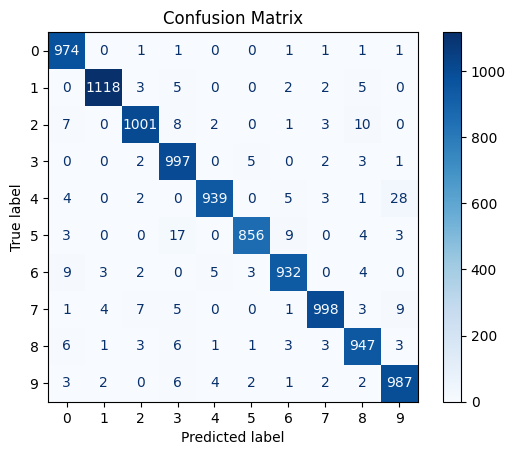

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert tensors to numpy arrays
y_test_np = y_test.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()

# Calculate the confusion matrix
cm = confusion_matrix(y_test_np, y_pred_np)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)) # Assuming 10 classes
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()